In [35]:
zscore_features = True

In [36]:
# load the features
import numpy as np
dinov3_fvs = np.load("outputs/dino_vit_hidden_states.npy")
dinov1_fvs = np.load("outputs/dino_v1_vit_hidden_states.npy")
sup_fvs = np.load("outputs/sup_vit_hidden_states.npy")

print("DINOv3 features shape:", dinov3_fvs.shape)
print("DINOv1 features shape:", dinov1_fvs.shape)
print("Supervised ViT features shape:", sup_fvs.shape)

DINOv3 features shape: (13, 32, 69, 768)
DINOv1 features shape: (13, 32, 65, 768)
Supervised ViT features shape: (13, 32, 65, 768)


In [37]:
# check if the feature dimensions are normalized
if zscore_features:
    dinov3_means = np.mean(dinov3_fvs, axis=-1)
    dinov1_means = np.mean(dinov1_fvs, axis=-1)
    sup_means = np.mean(sup_fvs, axis=-1)    
    dinov3_stds = np.std(dinov3_fvs, axis=-1)
    dinov1_stds = np.std(dinov1_fvs, axis=-1)
    sup_stds = np.std(sup_fvs, axis=-1)

    # zscore each feature dimension and check the means and stds again
    dinov3_fvs = (dinov3_fvs - dinov3_means[..., np.newaxis]) / dinov3_stds[..., np.newaxis]
    dinov1_fvs = (dinov1_fvs - dinov1_means[..., np.newaxis]) / dinov1_stds[..., np.newaxis]
    sup_fvs = (sup_fvs - sup_means[..., np.newaxis]) / sup_stds[..., np.newaxis]


In [38]:
# get the cls token and patch tokens for each model
dinov3_cls = dinov3_fvs[:, :, 0, :]
dinov3_patches = dinov3_fvs[:, :, 5:, :]
dinov3_patches_mean = dinov3_patches.mean(axis=2)
dinov1_cls = dinov1_fvs[:, :, 0, :]
dinov1_patches = dinov1_fvs[:, :, 1:, :]
dinov1_patches_mean = dinov1_patches.mean(axis=2)
sup_cls = sup_fvs[:, :, 0, :]
sup_patches = sup_fvs[:, :, 1:, :]
sup_patches_mean = sup_patches.mean(axis=2)

print("DINOv3 CLS token shape:", dinov3_cls.shape, dinov3_cls.min(), dinov3_cls.max())
print("DINOv3 patch tokens shape:", dinov3_patches.shape, dinov3_patches.min(), dinov3_patches.max())
print("DINOv1 CLS token shape:", dinov1_cls.shape, dinov1_cls.min(), dinov1_cls.max())
print("DINOv1 patch tokens shape:", dinov1_patches.shape, dinov1_patches.min(), dinov1_patches.max())
print("Supervised ViT CLS token shape:", sup_cls.shape, sup_cls.min(), sup_cls.max())
print("Supervised ViT patch tokens shape:", sup_patches.shape, sup_patches.min(), sup_patches.max())

DINOv3 CLS token shape: (13, 32, 768) -21.931643 24.911171
DINOv3 patch tokens shape: (13, 32, 64, 768) -24.771957 10.425513
DINOv1 CLS token shape: (13, 32, 768) -22.013153 9.960939
DINOv1 patch tokens shape: (13, 32, 64, 768) -12.182774 18.143625
Supervised ViT CLS token shape: (13, 32, 768) -11.261465 19.71049
Supervised ViT patch tokens shape: (13, 32, 64, 768) -14.0632 21.293264


In [39]:
nlayers = dinov3_cls.shape[0]
nimages = dinov3_cls.shape[1]

# reshape the features to be (nimages, nlayers, feature_dim)
dinov3_patches_reshaped = dinov3_patches.reshape(nlayers, nimages, -1)
dinov1_patches_reshaped = dinov1_patches.reshape(nlayers, nimages, -1)
sup_patches_reshaped = sup_patches.reshape(nlayers, nimages, -1)

print("DINOv3 patch tokens reshaped shape:", dinov3_patches_reshaped.shape)
print("DINOv1 patch tokens reshaped shape:", dinov1_patches_reshaped.shape)
print("Supervised ViT patch tokens reshaped shape:", sup_patches_reshaped.shape)

DINOv3 patch tokens reshaped shape: (13, 32, 49152)
DINOv1 patch tokens reshaped shape: (13, 32, 49152)
Supervised ViT patch tokens reshaped shape: (13, 32, 49152)


In [40]:
# insert path to the utils
import sys
sys.path.append("../utils")
import util


dinov3_rep_mat = util.compute_model_rep_mtx(dinov3_patches)
dinov1_rep_mat = util.compute_model_rep_mtx(dinov1_patches)
sup_rep_mat = util.compute_model_rep_mtx(sup_patches)

dinov3_invar_pair = util.compute_pair_inv_model(dinov3_rep_mat)
dinov1_invar_pair = util.compute_pair_inv_model(dinov1_rep_mat)
sup_invar_pair = util.compute_pair_inv_model(sup_rep_mat)

dinov3_rep_mat_cls = util.compute_model_rep_mtx(dinov3_cls)
dinov1_rep_mat_cls = util.compute_model_rep_mtx(dinov1_cls)
sup_rep_mat_cls = util.compute_model_rep_mtx(sup_cls)

dinov3_invar_pair_cls = util.compute_pair_inv_model(dinov3_rep_mat_cls)
dinov1_invar_pair_cls = util.compute_pair_inv_model(dinov1_rep_mat_cls)
sup_invar_pair_cls = util.compute_pair_inv_model(sup_rep_mat_cls)


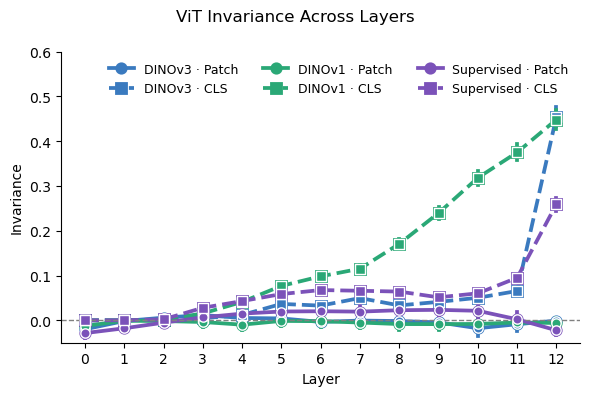

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

models = [
    {'data': dinov3_invar_pair,  'data_cls': dinov3_invar_pair_cls,  'color': '#3a7abf', 'label': 'DINOv3'},
    {'data': dinov1_invar_pair,  'data_cls': dinov1_invar_pair_cls,  'color': '#2aa876', 'label': 'DINOv1'},
    {'data': sup_invar_pair,     'data_cls': sup_invar_pair_cls,     'color': '#7b52b9', 'label': 'Supervised'},
]


fig, ax = plt.subplots(figsize=(6, 4))

for model in models:
    # Patch token (solid line)
    sns.pointplot(
        x="layer", y="pair_invariance",
        data=model['data'],
        color=model['color'],
        dodge=0,
        errorbar='se', linestyles='-', ax=ax,
        label=f"{model['label']} · Patch"
    )
    xvals = np.arange(model['data']['layer'].nunique())
    means = model['data'].groupby('layer')['pair_invariance'].mean().values
    ax.scatter(xvals, means, color=model['color'], edgecolor='white', s=45, zorder=3)

    # CLS token (dashed line)
    sns.pointplot(
        x="layer", y="pair_invariance",
        data=model['data_cls'],
        color=model['color'],
        dodge=0,
        errorbar='se', linestyles='--', ax=ax,
        label=f"{model['label']} · CLS",
        markers='s'
    )
    xvals_cls = np.arange(model['data_cls']['layer'].nunique())
    means_cls = model['data_cls'].groupby('layer')['pair_invariance'].mean().values
    ax.scatter(xvals_cls, means_cls, color=model['color'], edgecolor='white', s=45, marker='s', zorder=3)

ax.axhline(0, color='gray', lw=1, linestyle='--')
ax.set_xlabel("")
ax.set_ylabel("Invariance")
ax.set_xlabel("Layer")
ax.set_ylim(-0.05, 0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, ncol=3, fontsize=9)
plt.suptitle("ViT Invariance Across Layers")
plt.tight_layout()
plt.savefig("../figures/vit_invariance.png", dpi=300, bbox_inches='tight')
plt.show()

In [42]:
dinov3_rep_mat = util.compute_model_rep_mtx(dinov3_patches_mean)
dinov1_rep_mat = util.compute_model_rep_mtx(dinov1_patches_mean)
sup_rep_mat = util.compute_model_rep_mtx(sup_patches_mean)

dinov3_invar_pair = util.compute_pair_inv_model(dinov3_rep_mat)
dinov1_invar_pair = util.compute_pair_inv_model(dinov1_rep_mat)
sup_invar_pair = util.compute_pair_inv_model(sup_rep_mat)

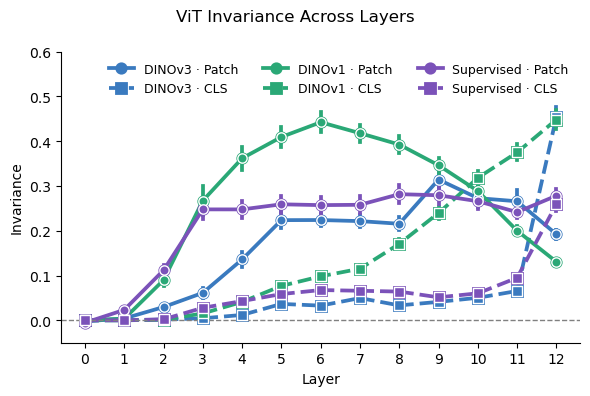

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

models = [
    {'data': dinov3_invar_pair,  'data_cls': dinov3_invar_pair_cls,  'color': '#3a7abf', 'label': 'DINOv3'},
    {'data': dinov1_invar_pair,  'data_cls': dinov1_invar_pair_cls,  'color': '#2aa876', 'label': 'DINOv1'},
    {'data': sup_invar_pair,     'data_cls': sup_invar_pair_cls,     'color': '#7b52b9', 'label': 'Supervised'},
]


fig, ax = plt.subplots(figsize=(6, 4))

for model in models:
    # Patch token (solid line)
    sns.pointplot(
        x="layer", y="pair_invariance",
        data=model['data'],
        color=model['color'],
        dodge=0,
        errorbar='se', linestyles='-', ax=ax,
        label=f"{model['label']} · Patch"
    )
    xvals = np.arange(model['data']['layer'].nunique())
    means = model['data'].groupby('layer')['pair_invariance'].mean().values
    ax.scatter(xvals, means, color=model['color'], edgecolor='white', s=45, zorder=3)

    # CLS token (dashed line)
    sns.pointplot(
        x="layer", y="pair_invariance",
        data=model['data_cls'],
        color=model['color'],
        dodge=0,
        errorbar='se', linestyles='--', ax=ax,
        label=f"{model['label']} · CLS",
        markers='s'
    )
    xvals_cls = np.arange(model['data_cls']['layer'].nunique())
    means_cls = model['data_cls'].groupby('layer')['pair_invariance'].mean().values
    ax.scatter(xvals_cls, means_cls, color=model['color'], edgecolor='white', s=45, marker='s', zorder=3)

ax.axhline(0, color='gray', lw=1, linestyle='--')
ax.set_xlabel("")
ax.set_ylabel("Invariance")
ax.set_xlabel("Layer")
ax.set_ylim(-0.05, 0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, ncol=3, fontsize=9)
plt.suptitle("ViT Invariance Across Layers")
plt.tight_layout()
plt.savefig("../figures/vit_invariance_patch_pool.png", dpi=300, bbox_inches='tight')
plt.show()